# HMM Workflow - Categorical HMM Training on Multi-Sequences

## This Notebook Covers
- Using the multi-length sequences to train HMM
- Experimenting different number of hidden states in HMM using AIC and BIC values and deciding n=8
- Training final HMM on Out-Of-Specification (OOS) dataset

## Libraries Used
- **Python:** pandas, numpy, matplotlib, seaborn, tqdm, hmmlearn

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from collections import Counter
from tqdm import tqdm
import time

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
sequences_df = pd.read_csv('data/cfpb_sequence_mapped_target_variable.csv')

In [3]:
sequences_df

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,complaint_idx,sequence_id,position_in_sequence,sequence_length
0,2024-02-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"Portfolio Recovery Associates, LLC",GA,30127,Web,Closed with explanation,Yes,NaN,i have been going through troubling times. i h...,have been going through troubling times. haven...,0.9297,0.047,0.831,0.121,0.0,0.0,0.0,1505,253,12,T12_reporting-agency_consumer-reporting,Credit Reporting Errors,Minimal,0,2024-02,0,0,0,1
1,2024-02-01,Credit card,General-purpose credit card or charge card,Closing your account,Company closed your account,SYNCHRONY FINANCIAL,ME,040XX,Web,Closed with explanation,Yes,NaN,i was told that because i always paid my entir...,was told that because always paid entire balan...,-0.7430,0.085,0.877,0.037,0.8,0.4,0.0,681,121,47,T47_loan_payment,Account / Payment Issues,Moderate,0,2024-02,1,1,0,1
2,2024-02-01,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,Kikoff Inc.,CA,90043,Web,Closed with explanation,Yes,NaN,i have request kickoff to submit to me informa...,have request kickoff submit information where ...,-0.1280,0.062,0.885,0.052,0.0,0.0,0.0,266,46,31,T31_letter_information,Account / Payment Issues,Minimal,0,2024-02,2,2,0,1
3,2024-02-01,Debt collection,Payday loan debt,Attempts to collect debt not owed,Debt was paid,"Upstart Holdings, Inc.",PA,187XX,Web,Closed with explanation,Yes,NaN,this company has been hounding me about a debt...,this company has been hounding about debt that...,-0.6124,0.135,0.865,0.000,0.0,0.0,0.0,164,34,10,T10_debt-collector_debt-collection,Debt Collection,Minimal,0,2024-02,3,3,0,1
4,2024-02-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",IN,46321,Web,Closed with explanation,Yes,NaN,"from what i know, as per fcra 605b, wrongly re...","from what know, per fcra 605b, wrongly reporte...",0.5055,0.089,0.763,0.148,0.0,0.0,0.0,282,47,33,T33_credit-report_credit-bureaus,Identity Theft / Fraud,Minimal,0,2024-02,4,4,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
965221,2025-11-30,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,Experian Information Solutions Inc.,GA,30253,Web,Closed with explanation,Yes,NaN,i am a xxxx xxxx xxxx xxxx. i recently discove...,. recently discovered that was listed part the...,0.1156,0.087,0.808,0.105,0.8,0.0,0.0,683,119,36,T36_identity-theft_theft-report,Identity Theft / Fraud,Minimal,0,2025-11,965221,623936,0,1
965222,2025-11-30,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,Experian Information Solutions Inc.,FL,33614,Web,Closed with explanation,Yes,NaN,i am very concerned about the items that are b...,very concerned about the items that are being ...,0.1984,0.094,0.783,0.124,0.0,0.0,0.0,276,51,39,T39_credit-report_inaccurate-accounts,Credit Reporting Errors,Minimal,0,2025-11,965222,600523,1,2
965223,2025-11-30,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,"EQUIFAX, INC.",GA,30324,Web,Closed with explanation,Yes,NaN,i am formally disputing the accuracy and owner...,formally disputing the accuracy and ownership ...,0.4754,0

In [4]:
multi_complaint_seq_ids = sequences_df[sequences_df['sequence_length'] > 1]['sequence_id'].unique()

print(f"\nSequence breakdown:")
print(f"  Total sequences: {sequences_df['sequence_id'].nunique():,}")
print(f"  Single-complaint: {(sequences_df['sequence_length'] == 1).sum():,} ({(sequences_df['sequence_length'] == 1).sum() / len(sequences_df) * 100:.1f}%)")
print(f"  Multi-complaint: {len(multi_complaint_seq_ids):,} ({len(multi_complaint_seq_ids) / sequences_df['sequence_id'].nunique() * 100:.1f}%)")


Sequence breakdown:
  Total sequences: 623,939
  Single-complaint: 443,543 (46.0%)
  Multi-complaint: 180,396 (28.9%)


In [5]:
# Filtering to multi-complaint only
sequences_multi = sequences_df[sequences_df['sequence_id'].isin(multi_complaint_seq_ids)].copy()

print(f"\nFiltered dataset (multi-complaint only):")
print(f"  Sequences: {sequences_multi['sequence_id'].nunique():,}")
print(f"  Complaints: {len(sequences_multi):,}")
print(f"  Avg sequence length: {sequences_multi.groupby('sequence_id')['sequence_length'].first().mean():.2f}")

length_dist = sequences_multi.groupby('sequence_id')['sequence_length'].first().value_counts().sort_index()
print("\nSequence length distribution (multi only):")
for length, count in length_dist.items():
    pct = count / sequences_multi['sequence_id'].nunique() * 100
    print(f"  {length} complaints: {count:,} ({pct:.1f}%)")


Filtered dataset (multi-complaint only):
  Sequences: 180,396
  Complaints: 521,683
  Avg sequence length: 2.89

Sequence length distribution (multi only):
  2 complaints: 83,146 (46.1%)
  3 complaints: 33,609 (18.6%)
  4 complaints: 63,641 (35.3%)


In [6]:
train_mask = (sequences_multi['Date received'] >= '2024-02-01') & (sequences_multi['Date received'] < '2025-08-01')
oot_mask = (sequences_multi['Date received'] >= '2025-08-01') & (sequences_multi['Date received'] < '2025-12-01')

train_data = sequences_multi[train_mask].copy()
oot_data = sequences_multi[oot_mask].copy()

print(f"\nTemporal splits:")
print(f"  Train (Feb 2024 - Jul 2025): {train_data['sequence_id'].nunique():,} sequences, {len(train_data):,} complaints")
print(f"  OOT (Aug 2025 - Nov 2025): {oot_data['sequence_id'].nunique():,} sequences, {len(oot_data):,} complaints")


Temporal splits:
  Train (Feb 2024 - Jul 2025): 155,369 sequences, 430,433 complaints
  OOT (Aug 2025 - Nov 2025): 41,646 sequences, 91,250 complaints


In [7]:
train_data.to_csv('data/cfpb_multi_sequence_oos.csv',index=False)
oot_data.to_csv('data/cfpb_multi_sequence_oot.csv',index=False)

In [8]:
print("="*80)
print("STATE ENCODING")
print("="*80)

print("\nUsing encoding: Tier × Sentiment\n")
    
def encode_state(row):
    tier = row['resolution_tier']    
    if row['sentiment_compound'] < -0.3:
        sentiment = 'Neg'
    elif row['sentiment_compound'] < 0.1:
        sentiment = 'Neu'
    else:
        sentiment = 'Pos'    
    return f"T{tier}_{sentiment}"

# Apply encoding
train_data['state'] = train_data.apply(encode_state, axis=1)

# Get unique states
unique_states = sorted(train_data['state'].unique())
n_states = len(unique_states)

print(f"Observable states: {n_states}")
print(f"\nState distribution (top 10):")
state_counts = train_data['state'].value_counts().head(10)
for state, count in state_counts.items():
    print(f"  {state:30s}: {count:6,}")

STATE ENCODING

Using encoding: Tier × Sentiment

Observable states: 9

State distribution (top 10):
  T0_Pos                        : 102,038
  T1_Pos                        : 99,343
  T0_Neg                        : 85,468
  T1_Neg                        : 84,621
  T1_Neu                        : 29,784
  T0_Neu                        : 26,951
  T2_Neg                        :  1,433
  T2_Pos                        :    571
  T2_Neu                        :    224


In [9]:
state_to_idx = {state: idx for idx, state in enumerate(unique_states)}
idx_to_state = {idx: state for state, idx in state_to_idx.items()}

print(f"\nState encoding complete")
print(f"State space size: {n_states}")


State encoding complete
State space size: 9


In [10]:
DEV_SUBSET_SIZE = 20000

print("\n" + "="*80)
print("PREPARING SEQUENCES FOR HMM")
print("="*80)

unique_sequences = train_data['sequence_id'].unique()

if len(unique_sequences) > DEV_SUBSET_SIZE:
    print(f"\n Using {DEV_SUBSET_SIZE:,} sequences (out of {len(unique_sequences):,})")
    np.random.seed(42)
    unique_sequences = np.random.choice(unique_sequences, DEV_SUBSET_SIZE, replace=False)
else:
    print(f"\nUsing full dataset: {len(unique_sequences):,} sequences")

# Convert to numeric sequences
sequences_numeric = []
sequence_lengths = []

print(f"\nProcessing {len(unique_sequences):,} sequences...")

for seq_id in tqdm(unique_sequences, desc="Converting sequences", unit="seq"):
    seq = train_data[train_data['sequence_id'] == seq_id].sort_values('position_in_sequence')
    
    # Convert states to indices
    state_sequence = [state_to_idx[s] for s in seq['state']]

    sequences_numeric.extend(state_sequence)
    sequence_lengths.append(len(state_sequence))

X = np.array(sequences_numeric).reshape(-1, 1)
lengths = np.array(sequence_lengths)

print(f"\nSequences prepared for HMM:")
print(f"  Total sequences: {len(lengths):,}")
print(f"  Total observations: {len(X):,}")
print(f"  Min sequence length: {lengths.min()}")
print(f"  Max sequence length: {lengths.max()}")
print(f"  Mean sequence length: {lengths.mean():.2f}")
print(f"  Median sequence length: {np.median(lengths):.0f}")

print(f"\nFormat verification:")
print(f"  X shape: {X.shape})")
print(f"  lengths shape: {lengths.shape})")


PREPARING SEQUENCES FOR HMM

 Using 20,000 sequences (out of 155,369)

Processing 20,000 sequences...


Converting sequences: 100%|████████████████████████████████████████████████████| 20000/20000 [00:20<00:00, 986.35seq/s]



Sequences prepared for HMM:
  Total sequences: 20,000
  Total observations: 55,417
  Min sequence length: 1
  Max sequence length: 4
  Mean sequence length: 2.77
  Median sequence length: 3

Format verification:
  X shape: (55417, 1))
  lengths shape: (20000,))


In [12]:
print("\n" + "="*80)
print("MODEL SELECTION - DETERMINING OPTIMAL HIDDEN STATES")
print("="*80)

SUBSET_SIZE = min(5000, len(lengths))
subset_lengths = lengths[:SUBSET_SIZE]
subset_X = X[:subset_lengths.sum()]

print(f"\nUsing subset for model selection:")
print(f"  Sequences: {len(subset_lengths):,}")
print(f"  Observations: {len(subset_X):,}")

# Test different numbers of components
n_components_range = range(3, 9)
bic_scores = []
aic_scores = []
log_likelihoods = []

print("\nTesting different numbers of hidden states...\n")

for n_comp in tqdm(n_components_range, desc="Evaluating HMM components"):
    model = hmm.CategoricalHMM(
        n_components=n_comp,
        n_features=n_states,
        n_iter=50,
        random_state=42,
        verbose=True
    )
    
    model.fit(subset_X, subset_lengths)
    
    log_likelihood = model.score(subset_X, subset_lengths)
    
    # Calculate BIC and AIC
    n_params = n_comp * (n_comp - 1) + n_comp * n_states  # Transition + emission params
    bic = -2 * log_likelihood + n_params * np.log(len(subset_X))
    aic = -2 * log_likelihood + 2 * n_params
    
    bic_scores.append(bic)
    aic_scores.append(aic)
    log_likelihoods.append(log_likelihood)
    
    print(f"  n_components={n_comp}: Log-likelihood={log_likelihood:.2f}, BIC={bic:.2f}, AIC={aic:.2f}")


MODEL SELECTION - DETERMINING OPTIMAL HIDDEN STATES

Using subset for model selection:
  Sequences: 5,000
  Observations: 13,853

Testing different numbers of hidden states...



Evaluating HMM components:   0%|                                                                 | 0/6 [00:00<?, ?it/s]         1  -31567.29933331             +nan
         2  -23530.46209713   +8036.83723618
         3  -23143.74791968    +386.71417745
         4  -22591.88978460    +551.85813508
         5  -22025.93279514    +565.95698946
         6  -21667.10745187    +358.82534327
         7  -21472.57610195    +194.53134992
         8  -21354.71499445    +117.86110750
         9  -21275.67870001     +79.03629445
        10  -21216.58112542     +59.09757458
        11  -21164.57260905     +52.00851637
        12  -21110.18079803     +54.39181102
        13  -21045.17283750     +65.00796053
        14  -20961.76218503     +83.41065247
        15  -20852.92654862    +108.83563641
        16  -20706.02619468    +146.90035393
        17  -20487.46123923    +218.56495545
        18  -20197.50904786    +289.95219137
        19  -19948.13547309    +249.37357477
        20  -19801.2771748

  n_components=3: Log-likelihood=-19467.65, BIC=39250.00, AIC=39001.30


         1  -31318.33403943             +nan
         2  -23184.78038061   +8133.55365882
         3  -22622.59053503    +562.18984557
         4  -22264.24689965    +358.34363539
         5  -21846.54627746    +417.70062218
         6  -21382.52763048    +464.01864698
         7  -21041.84930667    +340.67832382
         8  -20838.91147466    +202.93783200
         9  -20709.32175875    +129.58971591
        10  -20618.03698060     +91.28477815
        11  -20546.56431531     +71.47266529
        12  -20484.80922095     +61.75509436
        13  -20427.11953340     +57.68968755
        14  -20369.44791844     +57.67161496
        15  -20307.86808445     +61.57983399
        16  -20236.95169705     +70.91638740
        17  -20150.26161866     +86.69007839
        18  -20043.23854395    +107.02307471
        19  -19915.73806325    +127.50048069
        20  -19772.41668113    +143.32138212
        21  -19621.66793552    +150.74874561
        22  -19475.07288494    +146.59505059
        23

  n_components=4: Log-likelihood=-16771.78, BIC=34001.31, AIC=33639.57


...

  n_components=6: Log-likelihood=-16628.40, BIC=34057.85, AIC=33424.80


         1  -32097.73028017             +nan
         2  -23002.16888627   +9095.56139390
         3  -22781.26634998    +220.90253629
         4  -22649.32397879    +131.94237119
         5  -22482.56180411    +166.76217468
         6  -22260.19620367    +222.36560044
         7  -21987.46839648    +272.72780719
         8  -21667.11662888    +320.35176760
         9  -21333.48755912    +333.62906976
        10  -21070.24204448    +263.24551464
        11  -20906.18362947    +164.05841501
        12  -20807.48438416     +98.69924531
        13  -20743.08227449     +64.40210967
        14  -20696.69489160     +46.38738289
        15  -20660.28550324     +36.40938836
        16  -20629.65890953     +30.62659370
        17  -20602.10581142     +27.55309812
        18  -20575.17675985     +26.92905156
        19  -20545.97652059     +29.20023926
        20  -20510.55045275     +35.42606785
        21  -20463.23047969     +47.31997306
        22  -20396.26474093     +66.96573876
        23

  n_components=7: Log-likelihood=-18883.96, BIC=38769.23, AIC=37977.92


         1  -31086.71850230             +nan
         2  -22673.16137194   +8413.55713036
         3  -22018.23233407    +654.92903787
         4  -21471.30818883    +546.92414525
         5  -20993.42442831    +477.88376051
         6  -20587.50370519    +405.92072313
         7  -20278.92202238    +308.58168281
         8  -20041.86563187    +237.05639051
         9  -19834.93308786    +206.93254400
        10  -19630.60952188    +204.32356598
        11  -19406.89388661    +223.71563528
        12  -19145.36082283    +261.53306377
        13  -18867.59819945    +277.76262339
        14  -18639.49894890    +228.09925055
        15  -18480.62593633    +158.87301257
        16  -18356.13674199    +124.48919434
        17  -18225.39053727    +130.74620471
        18  -18054.92620626    +170.46433101
        19  -17818.82556421    +236.10064205
        20  -17501.22553157    +317.60003264
        21  -17148.14534237    +353.08018920
        22  -16878.74588265    +269.39945973
        23

  n_components=8: Log-likelihood=-16230.58, BIC=33681.80, AIC=32717.16


In [13]:
print("\n" + "="*80)
print("MODEL SELECTION - DETERMINING OPTIMAL HIDDEN STATES")
print("="*80)

SUBSET_SIZE = min(5000, len(lengths))
subset_lengths = lengths[:SUBSET_SIZE]
subset_X = X[:subset_lengths.sum()]

print(f"\nUsing subset for model selection:")
print(f"  Sequences: {len(subset_lengths):,}")
print(f"  Observations: {len(subset_X):,}")

# Test different numbers of components
n_components_range = range(3, 9)
bic_scores = []
aic_scores = []
log_likelihoods = []

print("\nTesting different numbers of hidden states...")
print("Using 10 random restarts per configuration to avoid local optima\n")

for n_comp in tqdm(n_components_range, desc="Evaluating HMM components"):
    best_log_likelihood = -np.inf
    best_model = None
    
    for seed in range(10):
        model = hmm.CategoricalHMM(
            n_components=n_comp,
            n_features=n_states,
            n_iter=100,
            random_state=42 + seed,
            verbose=False
        )
        
        model.fit(subset_X, subset_lengths)
        ll = model.score(subset_X, subset_lengths)
        
        if ll > best_log_likelihood:
            best_log_likelihood = ll
            best_model = model
    
    log_likelihood = best_log_likelihood
    
    n_params = (
        n_comp * (n_comp - 1) +      # Transition matrix (K rows, K-1 free params each)
        n_comp * (n_states - 1) +    # Emission probs (K states, V-1 free params each)
        (n_comp - 1)                 # Initial state distribution (K-1 free params)
    )
    
    bic = -2 * log_likelihood + n_params * np.log(len(subset_X))
    aic = -2 * log_likelihood + 2 * n_params
    
    bic_scores.append(bic)
    aic_scores.append(aic)
    log_likelihoods.append(log_likelihood)
    
    print(f"  n_components={n_comp}: Log-likelihood={log_likelihood:.2f}, BIC={bic:.2f}, AIC={aic:.2f}, n_params={n_params}")


MODEL SELECTION - DETERMINING OPTIMAL HIDDEN STATES

Using subset for model selection:
  Sequences: 5,000
  Observations: 13,853

Testing different numbers of hidden states...
Using 10 random restarts per configuration to avoid local optima



Evaluating HMM components:  17%|█████████▎                                              | 1/6 [11:58<59:51, 718.23s/it]

  n_components=3: Log-likelihood=-18462.86, BIC=37230.88, AIC=36989.72, n_params=32


Evaluating HMM components:  33%|██████████████████▋                                     | 2/6 [26:17<53:24, 801.06s/it]

  n_components=4: Log-likelihood=-16688.24, BIC=33824.67, AIC=33470.47, n_params=47


...

  n_components=6: Log-likelihood=-15902.76, BIC=32597.02, AIC=31971.51, n_params=83


Evaluating HMM components:  83%|█████████████████████████████████████████████         | 5/6 [1:08:38<13:54, 834.79s/it]

  n_components=7: Log-likelihood=-16047.25, BIC=33086.28, AIC=32302.51, n_params=104


Evaluating HMM components: 100%|██████████████████████████████████████████████████████| 6/6 [1:22:53<00:00, 828.98s/it]

  n_components=8: Log-likelihood=-15499.87, BIC=32210.85, AIC=31253.75, n_params=127


In [14]:
# Find optimal
optimal_bic = n_components_range[np.argmin(bic_scores)]
optimal_aic = n_components_range[np.argmin(aic_scores)]

print(f"\n" + "="*80)
print(f"Optimal by BIC: {optimal_bic} components (BIC={min(bic_scores):.2f})")
print(f"Optimal by AIC: {optimal_aic} components (AIC={min(aic_scores):.2f})")
print("="*80)

N_COMPONENTS = optimal_bic
print(f"\n Selected: {N_COMPONENTS} hidden states (via BIC)")


Optimal by BIC: 8 components (BIC=32210.85)
Optimal by AIC: 8 components (AIC=31253.75)

 Selected: 8 hidden states (via BIC)


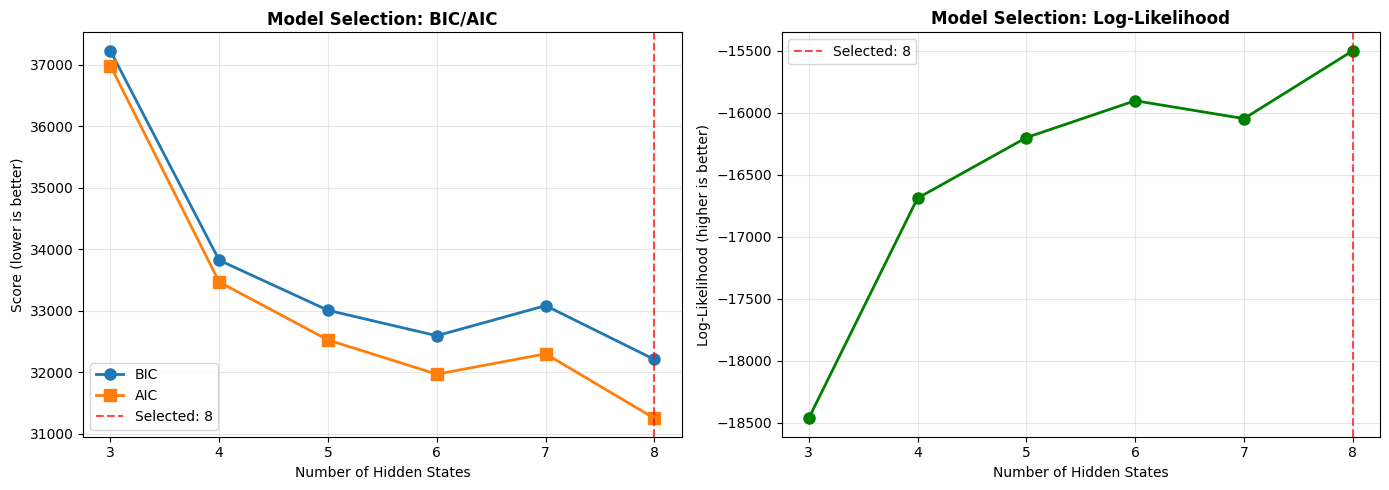

In [15]:
# Visualize model selection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BIC/AIC plot
ax1.plot(list(n_components_range), bic_scores, 'o-', label='BIC', linewidth=2, markersize=8)
ax1.plot(list(n_components_range), aic_scores, 's-', label='AIC', linewidth=2, markersize=8)
ax1.axvline(N_COMPONENTS, color='red', linestyle='--', alpha=0.7, label=f'Selected: {N_COMPONENTS}')
ax1.set_xlabel('Number of Hidden States')
ax1.set_ylabel('Score (lower is better)')
ax1.set_title('Model Selection: BIC/AIC', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Log-likelihood plot
ax2.plot(list(n_components_range), log_likelihoods, 'o-', color='green', linewidth=2, markersize=8)
ax2.axvline(N_COMPONENTS, color='red', linestyle='--', alpha=0.7, label=f'Selected: {N_COMPONENTS}')
ax2.set_xlabel('Number of Hidden States')
ax2.set_ylabel('Log-Likelihood (higher is better)')
ax2.set_title('Model Selection: Log-Likelihood', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/hmm_model_selection_categorical.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("\n" + "="*80)
print("TRAINING FINAL HMM MODEL")
print("="*80)

print(f"\nHMM configuration:")
print(f"  Model type: CategoricalHMM (for discrete observations)")
print(f"  Observable states: {n_states}")
print(f"  Hidden states: {N_COMPONENTS}")
print(f"  Max iterations: 100")
print(f"  Sequences: {len(lengths):,}")
print(f"  Observations: {len(X):,}")

final_model = hmm.CategoricalHMM(
    n_components=N_COMPONENTS,
    n_features=n_states,
    n_iter=100,
    random_state=42,
    verbose=True
)

print(f"\nTraining HMM on {len(X):,} observations from {len(lengths):,} sequences...\n")
final_model.fit(X, lengths)

print(f"\nTraining complete")
print(f"Converged: {final_model.monitor_.converged}")
print(f"Final log-likelihood: {final_model.score(X, lengths):.2f}")


TRAINING FINAL HMM MODEL

HMM configuration:
  Model type: CategoricalHMM (for discrete observations)
  Observable states: 9
  Hidden states: 8
  Max iterations: 100
  Sequences: 20,000
  Observations: 55,417

Training HMM on 55,417 observations from 20,000 sequences...



         1 -124319.76795726             +nan
         2  -90711.73868879  +33608.02926847
         3  -88165.17835582   +2546.56033297
         4  -86046.21049786   +2118.96785796
         5  -84197.40613961   +1848.80435825
         6  -82610.12017449   +1587.28596512
         7  -81402.77823467   +1207.34193982
         8  -80487.74528019    +915.03295448
         9  -79701.75736006    +785.98792013
        10  -78971.00074428    +730.75661578
        11  -78277.25004171    +693.75070257
        12  -77577.33803052    +699.91201118
        13  -76823.24764385    +754.09038667
        14  -75944.90950795    +878.33813590
        15  -74946.21025408    +998.69925387
        16  -73994.09136746    +952.11888662
        17  -73080.38222357    +913.70914389
        18  -72109.66021792    +970.72200565
        19  -71120.05314831    +989.60706962
        20  -70118.16365457   +1001.88949374
        21  -68956.46673174   +1161.69692284
        22  -67796.52682788   +1159.93990385
        23


Training complete
Converged: True
Final log-likelihood: -64545.70


       100  -64546.37761033      +0.69693584


In [17]:
print("\n" + "="*80)
print("TRANSITION MATRIX ANALYSIS")
print("="*80)

transition_matrix = final_model.transmat_

print(f"\nTransition matrix shape: {transition_matrix.shape}")
print(f"\nTransition probabilities:\n")
print(transition_matrix)

diagonal_values = np.diag(transition_matrix)
print(f"\nDiagonal values (self-transitions):")
for i, val in enumerate(diagonal_values):
    print(f"  H{i} → H{i}: {val:.4f}")

if np.any(diagonal_values > 0.95):
    print("\n Some states have >95% self-transition (very sticky states)")
else:
    print("\nTransitions look reasonable (no overly sticky states)")

# Find dominant transitions
print("\n" + "-"*80)
print("DOMINANT TRANSITIONS (probability > 0.10)")
print("-"*80)

for i in range(N_COMPONENTS):
    for j in range(N_COMPONENTS):
        if transition_matrix[i, j] > 0.10:
            print(f"H{i} → H{j}: {transition_matrix[i, j]:.3f}")


TRANSITION MATRIX ANALYSIS

Transition matrix shape: (8, 8)

Transition probabilities:

[[6.12810809e-007 3.84298202e-093 6.70724712e-001 4.08056202e-072
  2.78090720e-096 9.74757308e-006 9.95541491e-124 3.29264928e-001]
 [0.00000000e+000 8.36250492e-001 3.19612397e-241 1.45487755e-057
  7.64178604e-183 4.39879769e-007 0.00000000e+000 1.63749068e-001]
 [1.41371196e-008 4.48622269e-195 7.22080146e-001 3.78000643e-100
  6.27758874e-144 1.74801220e-012 0.00000000e+000 2.77919840e-001]
 [0.00000000e+000 2.84289475e-001 8.93223319e-237 5.72951563e-001
  3.32006874e-057 2.92948537e-003 0.00000000e+000 1.39829477e-001]
 [1.81107625e-030 4.01183490e-001 1.34645055e-029 3.70919063e-001
  1.13048512e-012 6.54775515e-002 1.15452129e-028 1.62419896e-001]
 [0.00000000e+000 8.55585129e-174 6.88975993e-241 1.74980521e-055
  1.03924767e-154 1.09871220e-004 0.00000000e+000 9.99890129e-001]
 [1.18334745e-002 1.70151695e-001 9.16671940e-002 4.40185955e-003
  1.31387708e-001 2.28417164e-002 5.67716352e-0

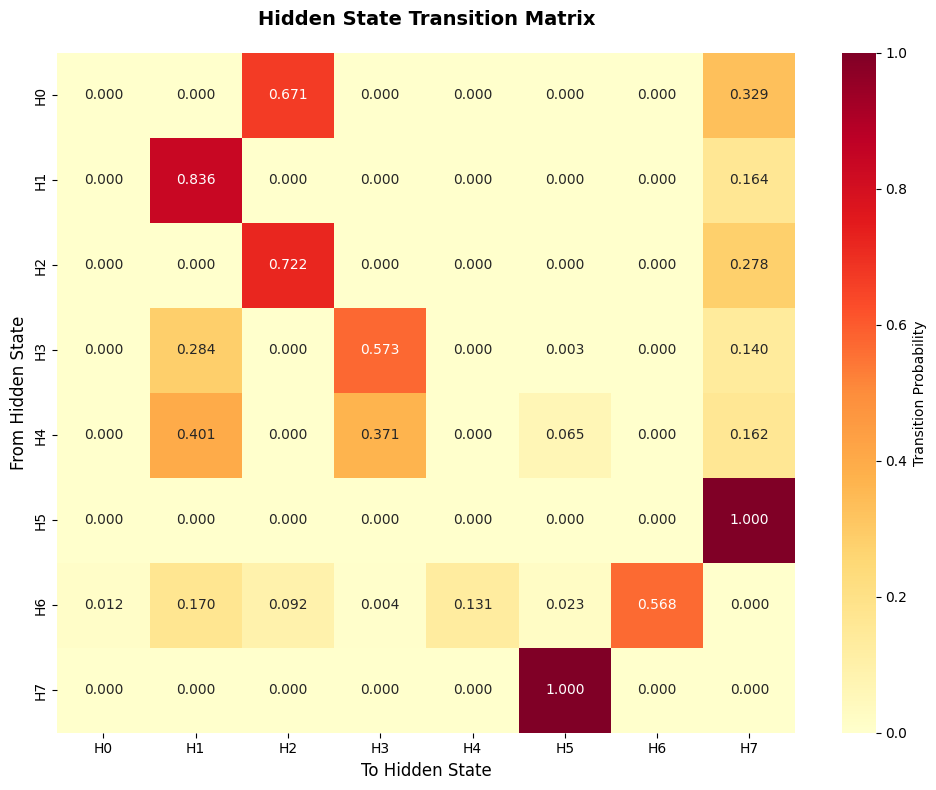


Transition matrix visualized


In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

short_labels = [f"H{i}" for i in range(N_COMPONENTS)]

sns.heatmap(transition_matrix, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            xticklabels=short_labels,
            yticklabels=short_labels,
            cbar_kws={'label': 'Transition Probability'},
            vmin=0, vmax=1)

ax.set_title('Hidden State Transition Matrix', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('From Hidden State', fontsize=12)
ax.set_xlabel('To Hidden State', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/hmm_transition_matrix_categorical.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTransition matrix visualized")

In [19]:
print("\n" + "="*80)
print("INTERPRETING HIDDEN STATES")
print("="*80)

# Predict hidden states for all sequences
hidden_states = final_model.predict(X, lengths)

train_subset = train_data[train_data['sequence_id'].isin(unique_sequences)].copy()
train_subset = train_subset.sort_values(['sequence_id', 'position_in_sequence']).reset_index(drop=True)
train_subset['hidden_state'] = hidden_states

hidden_state_profiles = {}

for h_state in range(N_COMPONENTS):
    mask = (train_subset['hidden_state'] == h_state)
    
    if mask.sum() == 0:
        continue
    
    subset = train_subset[mask]
    
    obs_states = subset['state'].value_counts().head(3)
    
    tier_dist = subset['resolution_tier'].value_counts(normalize=True).to_dict()
    avg_tier = subset['resolution_tier'].mean()
    avg_sentiment = subset['sentiment_compound'].mean()
    
    hidden_state_profiles[h_state] = {
        'count': mask.sum(),
        'percentage': mask.sum() / len(train_subset) * 100,
        'top_observed_states': obs_states.to_dict(),
        'tier_distribution': tier_dist,
        'avg_tier': avg_tier,
        'avg_sentiment': avg_sentiment
    }

print("\nHidden state profiles:\n")
for h_state, profile in sorted(hidden_state_profiles.items()):
    print("="*80)
    print(f"HIDDEN STATE {h_state}")
    print("="*80)
    print(f"Occurrences: {profile['count']:,} ({profile['percentage']:.1f}%)")
    print(f"\nCharacteristics:")
    print(f"  Avg tier: {profile['avg_tier']:.2f}")
    print(f"  Avg sentiment: {profile['avg_sentiment']:.3f}")
    
    print(f"\nTier distribution:")
    for tier in [0, 1, 2]:
        pct = profile['tier_distribution'].get(tier, 0) * 100
        if pct > 0:
            print(f"  Tier {tier}: {pct:5.1f}%")
    
    print(f"\nTop observable states:")
    for obs_state, count in list(profile['top_observed_states'].items()):
        print(f"  {obs_state}: {count:,}")
    print()


INTERPRETING HIDDEN STATES

Hidden state profiles:

HIDDEN STATE 0
Occurrences: 6,946 (12.5%)

Characteristics:
  Avg tier: 0.50
  Avg sentiment: -0.007

Tier distribution:
  Tier 0:  50.0%
  Tier 1:  49.6%
  Tier 2:   0.4%

Top observable states:
  T1_Pos: 1,661
  T0_Pos: 1,644
  T0_Neg: 1,383

HIDDEN STATE 1
Occurrences: 11,192 (20.2%)

Characteristics:
  Avg tier: 0.50
  Avg sentiment: -0.035

Tier distribution:
  Tier 0:  50.1%
  Tier 1:  49.4%
  Tier 2:   0.5%

Top observable states:
  T0_Pos: 2,622
  T1_Pos: 2,554
  T0_Neg: 2,294

HIDDEN STATE 2
Occurrences: 8,111 (14.6%)

Characteristics:
  Avg tier: 0.50
  Avg sentiment: -0.020

Tier distribution:
  Tier 0:  50.5%
  Tier 1:  49.1%
  Tier 2:   0.4%

Top observable states:
  T0_Pos: 1,977
  T1_Pos: 1,828
  T0_Neg: 1,648

HIDDEN STATE 3
Occurrences: 1,171 (2.1%)

Characteristics:
  Avg tier: 0.49
  Avg sentiment: -0.019

Tier distribution:
  Tier 0:  51.3%
  Tier 1:  48.3%
  Tier 2:   0.3%

Top observable states:
  T0_Pos: 280
  

In [21]:
train_subset

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,complaint_idx,sequence_id,position_in_sequence,sequence_length,state,hidden_state
0,2024-02-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",IN,46321,Web,Closed with explanation,Yes,NaN,"from what i know, as per fcra 605b, wrongly re...","from what know, per fcra 605b, wrongly reporte...",0.5055,0.089,0.763,0.148,0.0,0.0,0.0,282,47,33,T33_credit-report_credit-bureaus,Identity Theft / Fraud,Minimal,0,2024-02,4,4,0,2,T0_Pos,7
1,2024-03-21,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,"EQUIFAX, INC.",IN,46307,Web,Closed with non-monetary relief,Yes,NaN,i am extremely overwhelmed by the information ...,extremely overwhelmed the information that bei...,0.2014,0.042,0.886,0.072,0.0,0.0,0.0,316,57,33,T33_credit-report_credit-bureaus,Identity Theft / Fraud,Minimal,1,2024-03,43621,4,1,2,T1_Pos,5
2,2024-02-01,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MD,210XX,Web,Closed with non-monetary relief,Yes,NaN,in accordance with the fair credit reporting a...,accordance with the fair credit reporting act....,-0.0772,0.049,0.905,0.047,0.0,0.0,0.4,896,157,12,T12_reporting-agency_consumer-reporting,Credit Reporting Errors,Minimal,1,2024-02,62,62,0,2,T1_Neu,7
3,2024-02-22,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",MD,21045,Web,Closed with non-monetary relief,Yes,NaN,in accordance with the fair credit reporting a...,accordance with the fair credit reporting act....,-0.5719,0.058,0.903,0.039,0.0,0.0,0.4,1069,186,12,T12_reporting-agency_consumer-reporting,Credit Reporting Errors,Minimal,1,2024-02,16290,62,1,2,T1_Neg,5
4,2024-02-01,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,Experian Information Solutions Inc.,TX,77084,Web,Closed with explanation,Yes,NaN,i recently submitted a request for an investig...,recently submitted request for investigation t...,0.6486,0.082,0.752,0.166,0.0,0.0,0.0,337,53,37,T37_credit-reporting_fair-credit,Credit Reporting Errors,Minimal,0,2024-02,67,67,0,3,T0_Pos,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55412,2025-07-31,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",FL,339XX,Web,Closed with explanation,Yes,NaN,i am submitting this complaint to request imme...,submitting this complaint request immediate in...,0.8758,0.097,0.792,0.111,1.0,0.4,0.0,7071,1100,37,T37_credit-reporting_fair-credit,Credit Reporting Errors,Moderate,0,2025-07,787319,512333,0,2,T0_Pos,2
55413,2025-07-31,Credit reporting or other personal consumer re...,Credit reporting,Problem with a company's investigation into an...,Their investigation did not fix an error on yo...,Experian Information Solutions Inc.,TX,786XX,Web,Closed with explanation,Yes,NaN,i am filing this complaint regarding inaccurat...,filing this complaint regarding inaccurate and...,0.7073,0.059,0.844,0.097,0.0,0.0,0.0,842,142,37,T37_credit-reporting_fair-credit,Credi

In [22]:
train_subset['Date received'] = pd.to_datetime(train_subset['Date received'])

In [23]:
print("\n" + "="*80)
print("ESCALATION PATHWAY ANALYSIS")
print("="*80)

# Find sequences that escalated (tier increased)
escalation_sequences = []

for seq_id in unique_sequences:
    seq = train_subset[train_subset['sequence_id'] == seq_id].sort_values('position_in_sequence')
    
    if len(seq) > 1:
        initial_tier = seq.iloc[0]['resolution_tier']
        final_tier = seq.iloc[-1]['resolution_tier']
        
        if final_tier > initial_tier:
            # Get hidden state pathway
            hidden_pathway = seq['hidden_state'].tolist()
            
            escalation_sequences.append({
                'sequence_id': seq_id,
                'initial_tier': initial_tier,
                'final_tier': final_tier,
                'escalation_magnitude': final_tier - initial_tier,
                'sequence_length': len(seq),
                'hidden_pathway': ' → '.join([f"H{h}" for h in hidden_pathway]),
                'days_to_escalate': (seq.iloc[-1]['Date received'] - seq.iloc[0]['Date received']).days
            })

escalation_df = pd.DataFrame(escalation_sequences)

print(f"\nEscalation sequences: {len(escalation_df):,}")
print(f"Escalation rate: {len(escalation_df) / len(unique_sequences) * 100:.1f}%")
    
print(f"\nEscalation patterns:")
escalation_patterns = escalation_df.groupby(['initial_tier', 'final_tier']).size().reset_index(name='count')
escalation_patterns = escalation_patterns.sort_values('count', ascending=False)
print(escalation_patterns.to_string(index=False))
    
print(f"\nTime to escalate:")
print(f"  Mean: {escalation_df['days_to_escalate'].mean():.1f} days")
print(f"  Median: {escalation_df['days_to_escalate'].median():.1f} days")
    
# Most common escalation pathways
print(f"\nTop 10 escalation pathways:")
pathway_counts = escalation_df['hidden_pathway'].value_counts().head(10)
for pathway, count in pathway_counts.items():
    pct = count / len(escalation_df) * 100
    print(f"  {pathway}: {count:,} ({pct:.1f}%)")
    
# Save escalation data
escalation_df.to_csv('outputs/escalation_pathways_modeling.csv', index=False)
print("\nEscalation pathways saved")


ESCALATION PATHWAY ANALYSIS

Escalation sequences: 4,336
Escalation rate: 21.7%

Escalation patterns:
 initial_tier  final_tier  count
            0           1   4189
            0           2    130
            1           2     17

Time to escalate:
  Mean: 53.7 days
  Median: 50.0 days

Top 10 escalation pathways:
  H6 → H6: 186 (4.3%)
  H1 → H1: 179 (4.1%)
  H7 → H5: 162 (3.7%)
  H0 → H2: 129 (3.0%)
  H2 → H2: 118 (2.7%)
  H6 → H1: 71 (1.6%)
  H2 → H7: 69 (1.6%)
  H5 → H7: 63 (1.5%)
  H0 → H7: 62 (1.4%)
  H6 → H6 → H6: 53 (1.2%)

Escalation pathways saved


In [24]:
# Save model and metadata
hmm_dict = {
    'model': final_model,
    'model_type': 'CategoricalHMM',
    'n_components': N_COMPONENTS,
    'n_observable_states': n_states,
    'state_to_idx': state_to_idx,
    'idx_to_state': idx_to_state,
    'hidden_state_profiles': hidden_state_profiles,
    'transition_matrix': transition_matrix,
    'log_likelihood': final_model.score(X, lengths),
    'converged': final_model.monitor_.converged,
    'n_sequences': len(lengths),
    'n_observations': len(X)
}

with open('models/hmm_model_categorical_20k.pkl', 'wb') as f:
    pickle.dump(hmm_dict, f)

train_subset.to_csv('data/sequences_with_hidden_states_multi_20k.csv', index=False)

# Save summary
import json
summary = {
    'model_type': 'CategoricalHMM',
    'n_hidden_states': N_COMPONENTS,
    'n_observable_states': n_states,
    'n_sequences': len(lengths),
    'n_observations': len(X),
    'log_likelihood': float(final_model.score(X, lengths)),
    'converged': bool(final_model.monitor_.converged),
    'escalation_rate': float(len(escalation_df) / len(unique_sequences) * 100) if len(escalation_df) > 0 else 0.0,
    'avg_escalation_time_days': float(escalation_df['days_to_escalate'].mean()) if len(escalation_df) > 0 else 0.0,
    'multi_complaint_only': True
}

with open('outputs/hmm_summary_categorical_20k.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Summary saved to outputs/hmm_summary_categorical_20k.json")

Summary saved to outputs/hmm_summary_categorical_20k.json


In [25]:
state_to_idx

{'T0_Neg': 0,
 'T0_Neu': 1,
 'T0_Pos': 2,
 'T1_Neg': 3,
 'T1_Neu': 4,
 'T1_Pos': 5,
 'T2_Neg': 6,
 'T2_Neu': 7,
 'T2_Pos': 8}

In [26]:
idx_to_state

{0: 'T0_Neg',
 1: 'T0_Neu',
 2: 'T0_Pos',
 3: 'T1_Neg',
 4: 'T1_Neu',
 5: 'T1_Pos',
 6: 'T2_Neg',
 7: 'T2_Neu',
 8: 'T2_Pos'}

### Training HMM for Full OOS data

In [27]:
DEV_SUBSET_SIZE = 200000

print("\n" + "="*80)
print("PREPARING SEQUENCES FROM OOS DATA")
print("="*80)

unique_sequences = train_data['sequence_id'].unique()

if len(unique_sequences) > DEV_SUBSET_SIZE:
    print(f"\n Using {DEV_SUBSET_SIZE:,} sequences (out of {len(unique_sequences):,})")
    np.random.seed(42)
    unique_sequences = np.random.choice(unique_sequences, DEV_SUBSET_SIZE, replace=False)
else:
    print(f"\nUsing full dataset: {len(unique_sequences):,} sequences")

# Convert to numeric sequences
sequences_numeric = []
sequence_lengths = []

print(f"\nProcessing {len(unique_sequences):,} sequences...")

for seq_id in tqdm(unique_sequences, desc="Converting sequences", unit="seq"):
    seq = train_data[train_data['sequence_id'] == seq_id].sort_values('position_in_sequence')
    
    # Convert states to indices
    state_sequence = [state_to_idx[s] for s in seq['state']]

    sequences_numeric.extend(state_sequence)
    sequence_lengths.append(len(state_sequence))

X = np.array(sequences_numeric).reshape(-1, 1)
lengths = np.array(sequence_lengths)

print(f"\nSequences prepared for HMM:")
print(f"  Total sequences: {len(lengths):,}")
print(f"  Total observations: {len(X):,}")
print(f"  Min sequence length: {lengths.min()}")
print(f"  Max sequence length: {lengths.max()}")
print(f"  Mean sequence length: {lengths.mean():.2f}")
print(f"  Median sequence length: {np.median(lengths):.0f}")

print(f"\nFormat verification:")
print(f"  X shape: {X.shape})")
print(f"  lengths shape: {lengths.shape})")


PREPARING SEQUENCES FROM OOS DATA

Using full dataset: 155,369 sequences

Processing 155,369 sequences...


Converting sequences: 100%|█████████████████████████████████████████████████| 155369/155369 [01:55<00:00, 1350.06seq/s]


Sequences prepared for HMM:
  Total sequences: 155,369
  Total observations: 430,433
  Min sequence length: 1
  Max sequence length: 4
  Mean sequence length: 2.77
  Median sequence length: 3

Format verification:
  X shape: (430433, 1))
  lengths shape: (155369,))


In [28]:
print("\n" + "="*80)
print("TRAINING FINAL HMM MODEL")
print("="*80)

print(f"\nHMM configuration:")
print(f"  Model type: CategoricalHMM (for discrete observations)")
print(f"  Observable states: {n_states}")
print(f"  Hidden states: {N_COMPONENTS}")
print(f"  Max iterations: 100")
print(f"  Sequences: {len(lengths):,}")
print(f"  Observations: {len(X):,}")

final_model = hmm.CategoricalHMM(
    n_components=N_COMPONENTS,
    n_features=n_states,
    n_iter=100,
    random_state=42,
    verbose=True
)

print(f"\nTraining HMM on {len(X):,} observations from {len(lengths):,} sequences...\n")
final_model.fit(X, lengths)

print(f"\nTraining complete")
print(f"Converged: {final_model.monitor_.converged}")
print(f"Final log-likelihood: {final_model.score(X, lengths):.2f}")


TRAINING FINAL HMM MODEL

HMM configuration:
  Model type: CategoricalHMM (for discrete observations)
  Observable states: 9
  Hidden states: 8
  Max iterations: 100
  Sequences: 155,369
  Observations: 430,433

Training HMM on 430,433 observations from 155,369 sequences...



         1 -965604.20552061             +nan
         2 -705220.87868541 +260383.32683519
         3 -685378.98259231  +19841.89609310
         4 -668840.14426836  +16538.83832395
         5 -654512.94965745  +14327.19461091
         6 -642290.39648386  +12222.55317359
         7 -632962.20496740   +9328.19151646
         8 -625839.75277224   +7122.45219516
         9 -619730.10309223   +6109.64968002
        10 -614100.90122642   +5629.20186581
        11 -608894.12406253   +5206.77716389
        12 -603962.22763600   +4931.89642652
        13 -599019.80694795   +4942.42068805
        14 -593335.18799161   +5684.61895634
        15 -585850.64485648   +7484.54313513
        16 -576879.54508719   +8971.09976929
        17 -567968.82155382   +8910.72353336
        18 -559906.71363678   +8062.10791705
        19 -553270.74846660   +6635.96517017
        20 -547294.84852412   +5975.89994249
        21 -539776.53281114   +7518.31571298
        22 -530463.60022112   +9312.93259002
        23


Training complete
Converged: True
Final log-likelihood: -502587.99


In [29]:
print("\n" + "="*80)
print("TRANSITION MATRIX ANALYSIS")
print("="*80)

transition_matrix = final_model.transmat_

print(f"\nTransition matrix shape: {transition_matrix.shape}")
print(f"\nTransition probabilities:\n")
print(transition_matrix)

diagonal_values = np.diag(transition_matrix)
print(f"\nDiagonal values (self-transitions):")
for i, val in enumerate(diagonal_values):
    print(f"  H{i} → H{i}: {val:.4f}")

if np.any(diagonal_values > 0.95):
    print("\n Some states have >95% self-transition (very sticky states)")
else:
    print("\nTransitions look reasonable (no overly sticky states)")

# Find dominant transitions
print("\n" + "-"*80)
print("DOMINANT TRANSITIONS (probability > 0.10)")
print("-"*80)

for i in range(N_COMPONENTS):
    for j in range(N_COMPONENTS):
        if transition_matrix[i, j] > 0.10:
            print(f"H{i} → H{j}: {transition_matrix[i, j]:.3f}")


TRANSITION MATRIX ANALYSIS

Transition matrix shape: (8, 8)

Transition probabilities:

[[1.34697299e-006 5.37353773e-095 6.70642231e-001 9.33356655e-023
  6.03029195e-066 8.67404051e-006 1.42814821e-121 3.29347748e-001]
 [0.00000000e+000 8.31865863e-001 1.05611336e-231 1.42569831e-058
  2.28907784e-187 6.44500635e-007 0.00000000e+000 1.68133493e-001]
 [4.12078023e-008 2.77493142e-181 7.22094269e-001 2.63003671e-078
  1.85280681e-139 2.00800909e-012 0.00000000e+000 2.77905689e-001]
 [0.00000000e+000 2.53481212e-001 3.73449025e-238 6.06910020e-001
  4.75291529e-056 9.92671580e-004 0.00000000e+000 1.38616096e-001]
 [9.99881437e-032 4.05691311e-001 4.87823881e-031 3.61868325e-001
  5.28338561e-013 7.35893174e-002 1.83634613e-029 1.58851046e-001]
 [0.00000000e+000 5.84686927e-173 4.02831873e-227 8.00599766e-083
  3.07540321e-185 8.83025725e-005 0.00000000e+000 9.99911697e-001]
 [1.53777470e-002 1.62973851e-001 9.42322202e-002 3.46817326e-003
  1.29119808e-001 2.59227172e-002 5.68905483e-0

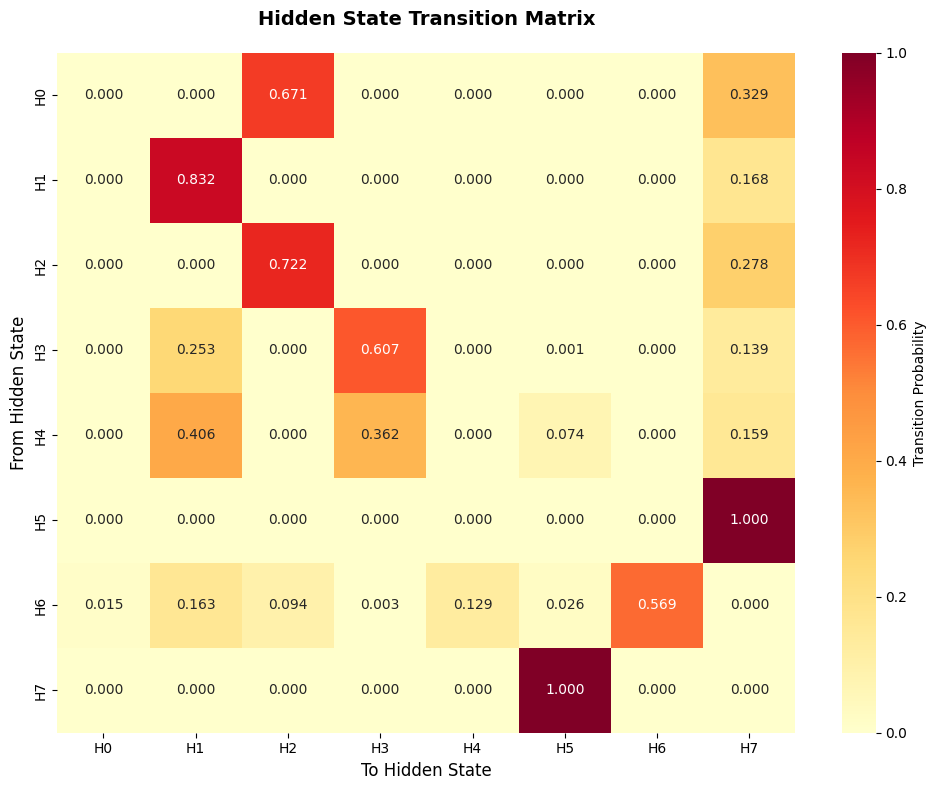


Transition matrix visualized


In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

short_labels = [f"H{i}" for i in range(N_COMPONENTS)]

sns.heatmap(transition_matrix, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            xticklabels=short_labels,
            yticklabels=short_labels,
            cbar_kws={'label': 'Transition Probability'},
            vmin=0, vmax=1)

ax.set_title('Hidden State Transition Matrix', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('From Hidden State', fontsize=12)
ax.set_xlabel('To Hidden State', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/hmm_transition_matrix_categorical_oos.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTransition matrix visualized")

In [31]:
print("\n" + "="*80)
print("INTERPRETING HIDDEN STATES")
print("="*80)

# Predict hidden states for all sequences
hidden_states = final_model.predict(X, lengths)

train_subset = train_data[train_data['sequence_id'].isin(unique_sequences)].copy()
train_subset = train_subset.sort_values(['sequence_id', 'position_in_sequence']).reset_index(drop=True)
train_subset['hidden_state'] = hidden_states

hidden_state_profiles = {}

for h_state in range(N_COMPONENTS):
    mask = (train_subset['hidden_state'] == h_state)
    
    if mask.sum() == 0:
        continue
    
    subset = train_subset[mask]
    
    obs_states = subset['state'].value_counts().head(3)
    
    tier_dist = subset['resolution_tier'].value_counts(normalize=True).to_dict()
    avg_tier = subset['resolution_tier'].mean()
    avg_sentiment = subset['sentiment_compound'].mean()
    
    hidden_state_profiles[h_state] = {
        'count': mask.sum(),
        'percentage': mask.sum() / len(train_subset) * 100,
        'top_observed_states': obs_states.to_dict(),
        'tier_distribution': tier_dist,
        'avg_tier': avg_tier,
        'avg_sentiment': avg_sentiment
    }

print("\nHidden state profiles:\n")
for h_state, profile in sorted(hidden_state_profiles.items()):
    print("="*80)
    print(f"HIDDEN STATE {h_state}")
    print("="*80)
    print(f"Occurrences: {profile['count']:,} ({profile['percentage']:.1f}%)")
    print(f"\nCharacteristics:")
    print(f"  Avg tier: {profile['avg_tier']:.2f}")
    print(f"  Avg sentiment: {profile['avg_sentiment']:.3f}")
    
    print(f"\nTier distribution:")
    for tier in [0, 1, 2]:
        pct = profile['tier_distribution'].get(tier, 0) * 100
        if pct > 0:
            print(f"  Tier {tier}: {pct:5.1f}%")
    
    print(f"\nTop observable states:")
    for obs_state, count in list(profile['top_observed_states'].items()):
        print(f"  {obs_state}: {count:,}")
    print()


INTERPRETING HIDDEN STATES

Hidden state profiles:

HIDDEN STATE 0
Occurrences: 53,395 (12.4%)

Characteristics:
  Avg tier: 0.69
  Avg sentiment: 0.697

Tier distribution:
  Tier 0:  30.9%
  Tier 1:  69.1%

Top observable states:
  T1_Pos: 36,903
  T0_Pos: 16,492

HIDDEN STATE 1
Occurrences: 85,774 (19.9%)

Characteristics:
  Avg tier: 0.01
  Avg sentiment: -0.766

Tier distribution:
  Tier 0:  99.6%
  Tier 2:   0.4%

Top observable states:
  T0_Neg: 85,468
  T2_Neg: 306

HIDDEN STATE 2
Occurrences: 62,590 (14.5%)

Characteristics:
  Avg tier: 1.00
  Avg sentiment: 0.567

Tier distribution:
  Tier 1:  99.8%
  Tier 2:   0.2%

Top observable states:
  T1_Pos: 62,440
  T2_Neg: 97
  T2_Pos: 38

HIDDEN STATE 3
Occurrences: 9,705 (2.3%)

Characteristics:
  Avg tier: 0.22
  Avg sentiment: -0.163

Tier distribution:
  Tier 0:  88.8%
  Tier 1:   0.1%
  Tier 2:  11.1%

Top observable states:
  T0_Neu: 8,622
  T2_Neg: 832
  T2_Neu: 159

HIDDEN STATE 4
Occurrences: 20,278 (4.7%)

Characteristics

In [32]:
train_subset

,Date received,Product,Sub-product,Issue,Sub-issue,Company,State,ZIP code,Submitted via,Company response to consumer,Timely response?,Consumer disputed?,narrative_clean,narrative_for_lda,sentiment_compound,sentiment_neg,sentiment_neu,sentiment_pos,urgency_score,churn_intent,loyalty_score,text_length,word_count,dominant_topic,topic_granular,topic_category,churn_risk_tier,resolution_tier,year_month,complaint_idx,sequence_id,position_in_sequence,sequence_length,state,hidden_state
0,2024-02-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",IN,46321,Web,Closed with explanation,Yes,NaN,"from what i know, as per fcra 605b, wrongly re...","from what know, per fcra 605b, wrongly reporte...",0.5055,0.089,0.763,0.148,0.0,0.0,0.0,282,47,33,T33_credit-report_credit-bureaus,Identity Theft / Fraud,Minimal,0,2024-02,4,4,0,2,T0_Pos,0
1,2024-03-21,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,"EQUIFAX, INC.",IN,46307,Web,Closed with non-monetary relief,Yes,NaN,i am extremely overwhelmed by the information ...,extremely overwhelmed the information that bei...,0.2014,0.042,0.886,0.072,0.0,0.0,0.0,316,57,33,T33_credit-report_credit-bureaus,Identity Theft / Fraud,Minimal,1,2024-03,43621,4,1,2,T1_Pos,2
2,2024-02-01,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",TX,76036,Web,Closed with explanation,Yes,NaN,i respectfully ask that you eliminate this inc...,respectfully ask that you eliminate this incor...,0.5544,0.108,0.692,0.200,0.0,0.0,0.0,204,32,9,T09_credit-report_credit-reporting,Credit Reporting Errors,Minimal,0,2024-02,5,5,0,4,T0_Pos,0
3,2024-02-13,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"EQUIFAX, INC.",TX,76021,Web,Closed with non-monetary relief,Yes,NaN,kindly address this issue on my credit report....,kindly address this issue credit report. asser...,0.4118,0.130,0.679,0.191,1.0,0.0,0.0,210,36,9,T09_credit-report_credit-reporting,Credit Reporting Errors,Minimal,1,2024-02,9036,5,1,4,T1_Pos,2
4,2024-03-13,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,"EQUIFAX, INC.",TX,76063,Web,Closed with non-monetary relief,Yes,NaN,i am formally notifying your company that i di...,formally notifying your company that did not p...,-0.2828,0.080,0.855,0.065,0.0,0.0,0.0,774,127,9,T09_credit-report_credit-reporting,Credit Reporting Errors,Minimal,1,2024-03,35046,5,2,4,T1_Neu,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430428,2025-07-31,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,"EQUIFAX, INC.",FL,333XX,Web,Closed with explanation,Yes,NaN,applications were made in my name without my k...,applications were made name without knowledge ...,0.9374,0.000,0.794,0.206,0.8,0.0,0.0,461,74,26,T26_did-authorize_unauthorized-inquiries,General Complaints,Minimal,0,2025-07,787481,512423,0,2,T0_Pos,6
430429,2025-07-31,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,78251,Web,Closed with explanation,Yes,NaN,i am a victim of human trafficking of debt bon...,victim human trafficking debt bondage and woul...,-0.7506,0.062,0.922,0.016,0.8,0.0,0.0,786,152,6,T06_credit-reporting_fair-credit,Credit Reporting Errors,Minimal,0,2025-07,787483,512425,0,4,T0_Neg,1
430430,2025-07-31,Credit reporting or other personal consumer re...,Credit reporting,In

In [33]:
train_subset['Date received'] = pd.to_datetime(train_subset['Date received'])

In [34]:
print("\n" + "="*80)
print("ESCALATION PATHWAY ANALYSIS")
print("="*80)

# Find sequences that escalated (tier increased)
escalation_sequences = []

for seq_id in unique_sequences:
    seq = train_subset[train_subset['sequence_id'] == seq_id].sort_values('position_in_sequence')
    
    if len(seq) > 1:
        initial_tier = seq.iloc[0]['resolution_tier']
        final_tier = seq.iloc[-1]['resolution_tier']
        
        if final_tier > initial_tier:
            # Get hidden state pathway
            hidden_pathway = seq['hidden_state'].tolist()
            
            escalation_sequences.append({
                'sequence_id': seq_id,
                'initial_tier': initial_tier,
                'final_tier': final_tier,
                'escalation_magnitude': final_tier - initial_tier,
                'sequence_length': len(seq),
                'hidden_pathway': ' → '.join([f"H{h}" for h in hidden_pathway]),
                'days_to_escalate': (seq.iloc[-1]['Date received'] - seq.iloc[0]['Date received']).days
            })

escalation_df = pd.DataFrame(escalation_sequences)

print(f"\nEscalation sequences: {len(escalation_df):,}")
print(f"Escalation rate: {len(escalation_df) / len(unique_sequences) * 100:.1f}%")
    
print(f"\nEscalation patterns:")
escalation_patterns = escalation_df.groupby(['initial_tier', 'final_tier']).size().reset_index(name='count')
escalation_patterns = escalation_patterns.sort_values('count', ascending=False)
print(escalation_patterns.to_string(index=False))
    
print(f"\nTime to escalate:")
print(f"  Mean: {escalation_df['days_to_escalate'].mean():.1f} days")
print(f"  Median: {escalation_df['days_to_escalate'].median():.1f} days")
    
# Most common escalation pathways
print(f"\nTop 10 escalation pathways:")
pathway_counts = escalation_df['hidden_pathway'].value_counts().head(10)
for pathway, count in pathway_counts.items():
    pct = count / len(escalation_df) * 100
    print(f"  {pathway}: {count:,} ({pct:.1f}%)")
    
# Save escalation data
escalation_df.to_csv('outputs/escalation_pathways_modeling_oos.csv', index=False)
print("\nEscalation pathways saved")


ESCALATION PATHWAY ANALYSIS

Escalation sequences: 33,454
Escalation rate: 21.5%

Escalation patterns:
 initial_tier  final_tier  count
            0           1  32215
            0           2   1070
            1           2    169

Time to escalate:
  Mean: 53.3 days
  Median: 50.0 days

Top 10 escalation pathways:
  H0 → H2: 4,286 (12.8%)
  H0 → H7: 3,842 (11.5%)
  H1 → H7: 2,894 (8.7%)
  H0 → H2 → H2 → H2: 2,586 (7.7%)
  H1 → H7 → H5 → H7: 1,528 (4.6%)
  H4 → H7: 1,522 (4.5%)
  H0 → H7 → H5 → H7: 1,143 (3.4%)
  H0 → H2 → H2: 1,063 (3.2%)
  H0 → H7 → H5: 985 (2.9%)
  H0 → H2 → H2 → H7: 934 (2.8%)

Escalation pathways saved


In [35]:
# Save model and metadata
hmm_dict = {
    'model': final_model,
    'model_type': 'CategoricalHMM',
    'n_components': N_COMPONENTS,
    'n_observable_states': n_states,
    'state_to_idx': state_to_idx,
    'idx_to_state': idx_to_state,
    'hidden_state_profiles': hidden_state_profiles,
    'transition_matrix': transition_matrix,
    'log_likelihood': final_model.score(X, lengths),
    'converged': final_model.monitor_.converged,
    'n_sequences': len(lengths),
    'n_observations': len(X)
}

with open('models/hmm_model_categorical_oos.pkl', 'wb') as f:
    pickle.dump(hmm_dict, f)

train_subset.to_csv('data/sequences_with_hidden_states_multi_oos.csv', index=False)

# Save summary
import json
summary = {
    'model_type': 'CategoricalHMM',
    'n_hidden_states': N_COMPONENTS,
    'n_observable_states': n_states,
    'n_sequences': len(lengths),
    'n_observations': len(X),
    'log_likelihood': float(final_model.score(X, lengths)),
    'converged': bool(final_model.monitor_.converged),
    'escalation_rate': float(len(escalation_df) / len(unique_sequences) * 100) if len(escalation_df) > 0 else 0.0,
    'avg_escalation_time_days': float(escalation_df['days_to_escalate'].mean()) if len(escalation_df) > 0 else 0.0,
    'multi_complaint_only': True
}

with open('outputs/hmm_summary_categorical_oos.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Summary saved to outputs/hmm_summary_categorical_oos.json")

Summary saved to outputs/hmm_summary_categorical_oos.json
